**IIC3912 - Tópicos Avanzados de Gráfica Computacional**\
Francisca T. Gil-Ureta ⋅ 2026

# **Clase 7 | Ray Tracing**

## Pintando cada pixel


In [1]:
import numpy as np
from dataclasses import dataclass

import plotly.graph_objects as go

In [2]:
@dataclass
class ImagePlane:
    width: int
    height: int
    left: float
    right: float
    top: float
    bottom: float

class OrtoCamera:
    def __init__(self, position, look_at, up):
        self.position = np.array(position).astype(float)
        self.look_at = np.array(look_at).astype(float)
        self.up =  np.array(up).astype(float)

        # compute frame
        self.e = self.position
        self.w = - (look_at - self.e)
        self.w = self.w / np.linalg.norm(self.w)
        self.u = np.cross(self.up, self.w)
        self.v = np.cross(self.w, self.u)
        

In [3]:
def sample_pixels_orto(image:ImagePlane, camera:OrtoCamera):
    l = image.left
    r = image.right
    t = image.top
    b = image.bottom

    pixels = []
    for i in range(0, image.width):
        for j in range(0, image.height):
            u = l + (r - l) * (i + 0.5) / image.width
            v = b + (t - b) * (j + 0.5) / image.height
            pixel_center = camera.e + u * camera.u + v * camera.v 
            pixels.append(pixel_center)
    return np.array(pixels)

def sample_rays_orto(pixels, camera:OrtoCamera):
    rays = np.empty((pixels.shape[0], 6), dtype=np.float64)
    rays[:,:3] = pixels
    rays[:,3:] = - camera.w
    return rays

In [37]:
def unpack(vec):
    return dict(x=vec[:,0], y=vec[:,1], z=vec[:,2])
    
def point_dir(p, d):
    return np.array([p, p + d, [None, None, None]])
    
def show(camera, image_plane, pixels=None, rays=None, hit_mask=None):
    data = []
    
    # draw camera axis
    data.append(
            go.Scatter3d(**unpack(point_dir(camera.e, camera.up)), mode='markers+lines', marker=dict(size=1), name='up')
    )
    data.append(
            go.Scatter3d(**unpack(point_dir(camera.e, camera.w)), mode='markers+lines', marker=dict(size=1), name='w')
    )

    if (pixels is not None):
        markers= dict(size=2)
        if (hit_mask is not None):
            c = ["#ff0000","#00ff00"] 
            markers['color'] = [c[0 if i else 1] for i in hit_mask]
            
        data.append(
            go.Scatter3d(**unpack(pixels), mode='markers', marker=markers, name='pixels'))

    if (rays is not None):
        segments = np.empty((rays.shape[0] * 3, 3), dtype=rays.dtype)
        segments[0::3,:] = rays[:,:3]
        segments[1::3,:] = rays[:,:3] + rays[:,3:]
        segments[2::3,:] = None

        data.append(
            go.Scatter3d(**unpack(segments), mode='markers+lines', marker=dict(size=1), name='rays'))
        
    figure = go.Figure(data=data,layout=go.Layout(scene=dict(aspectmode='data')))
    figure.update_layout(margin=dict(l=0, r=0, t=0, b=0), scene_camera=dict(up=dict(x=0.0, y=1.0, z=0.0)))
    return figure.show()


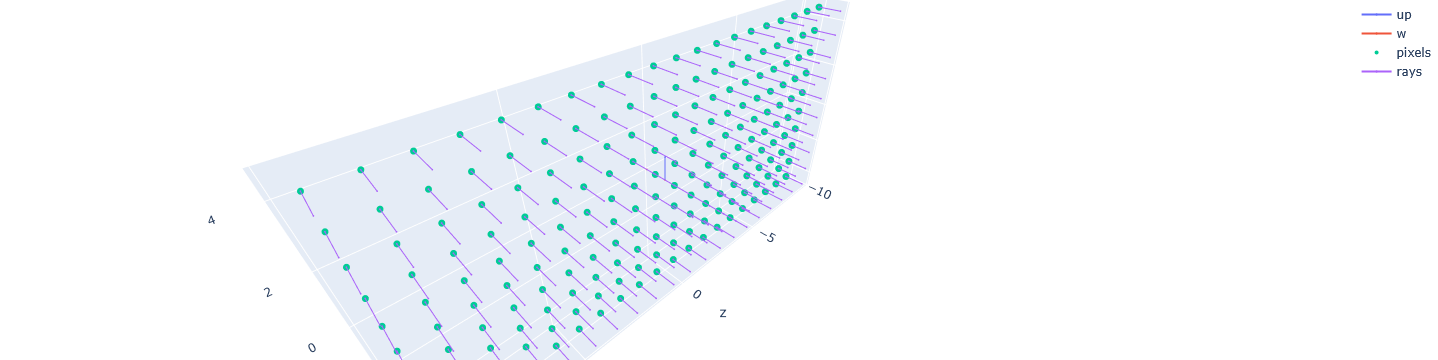

In [27]:
def orto_example():
    image = ImagePlane(width=20, height=10, left=-10.0, right=10.0, top=5.0, bottom=-5.0)
    camera = OrtoCamera(position=[-10,0,0], look_at=[0,0,0], up=[0,1,0])
    
    pixels = sample_pixels_orto(image, camera)
    rays = sample_rays_orto(pixels, camera)
    
    return show(camera, image, pixels=pixels, rays=rays)
orto_example()

## Ray Intersection

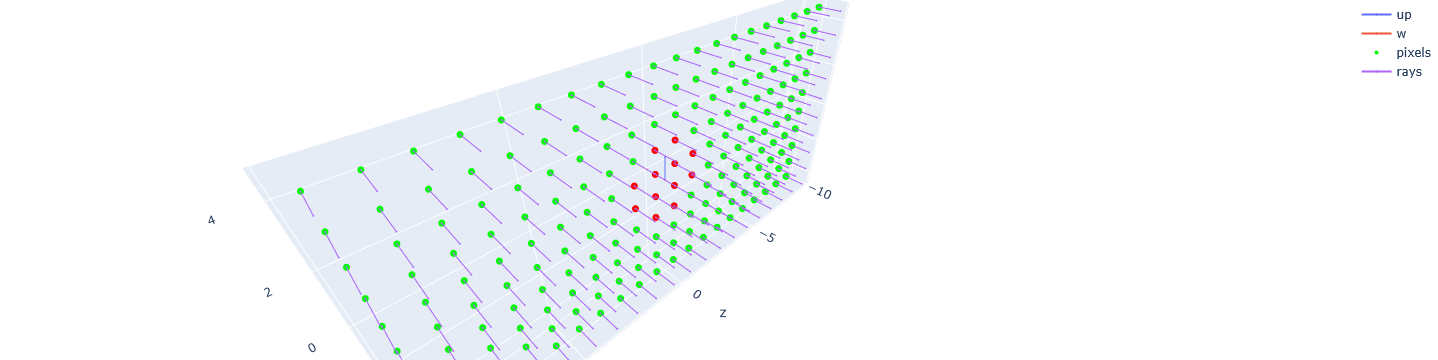

In [31]:
class Sphere:
    def __init__(self, center, radius:float):
        self.radius = radius
        self.center = np.array(center)

    def hit(self, rays):
        origins = rays[:, :3]  
        directions = rays[:, 3:]
        
        oc = origins - self.center
        a = np.sum(directions * directions, axis=1) # same as dot product
        b = 2.0 * np.sum(oc * directions, axis=1) # same as dot product
        c = np.sum(oc * oc, axis=1) - self.radius ** 2

        discriminant = b**2 - 4.0 * a * c                       # (N,)
        hit_mask = discriminant >= 0.0

        return hit_mask
        
        
def example_sphere_intersection():
    image = ImagePlane(width=20, height=10, left=-10.0, right=10.0, top=5.0, bottom=-5.0)
    camera = OrtoCamera(position=[-10,0,0], look_at=[0,0,0], up=[0,1,0])
    
    pixels = sample_pixels_orto(image, camera)
    rays = sample_rays_orto(pixels, camera)

    sphere = Sphere(center = [10,0,0], radius=2.0)
    hit_mask = sphere.hit(rays)
    return show(camera, image, pixels=pixels, rays=rays, hit_mask=hit_mask)
        
example_sphere_intersection()

# Implementar lo mismo para la cámara de perspectiva

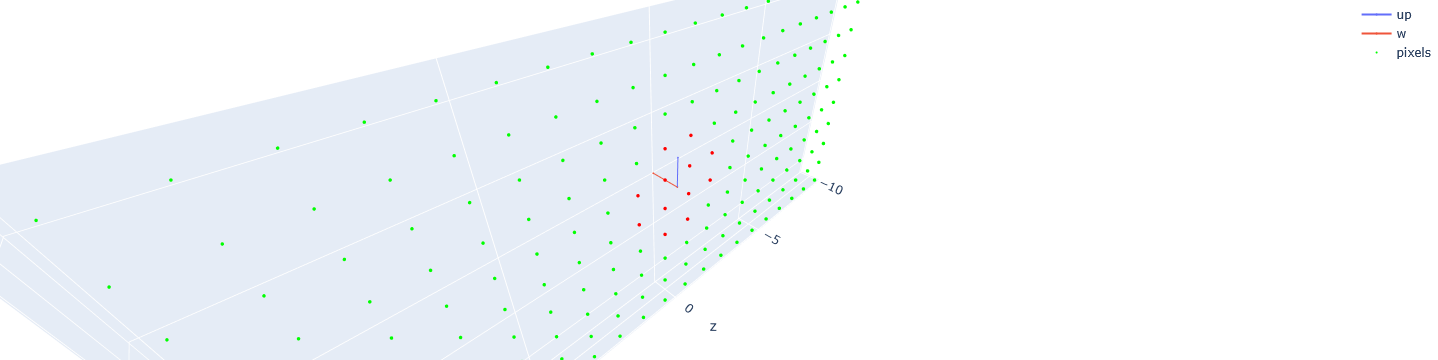

In [47]:
# el codigo fue copiado de la camerara ortografica, cómo modificarlo para que implemente la cámara de perspectiva?

def perpective_example():
    class PerspCamera:
        def __init__(self, position, look_at, up, focal_length):
            self.position = np.array(position).astype(float)
            self.look_at = np.array(look_at).astype(float)
            self.up =  np.array(up).astype(float)
    
            # compute frame
            self.e = self.position
            self.w = - (look_at - self.e)
            self.w = self.w / np.linalg.norm(self.w)
            self.u = np.cross(self.up, self.w)
            self.v = np.cross(self.w, self.u)
    
    def sample_pixels(image:ImagePlane, camera:OrtoCamera):
        l = image.left
        r = image.right
        t = image.top
        b = image.bottom
    
        pixels = []
        for i in range(0, image.width):
            for j in range(0, image.height):
                u = l + (r - l) * (i + 0.5) / image.width
                v = b + (t - b) * (j + 0.5) / image.height
                pixel_center = camera.e + u * camera.u + v * camera.v 
                pixels.append(pixel_center)
        return np.array(pixels)
    
    def sample_rays(pixels, camera:PerspCamera):
        rays = np.empty((pixels.shape[0], 6), dtype=np.float64)
        rays[:,:3] = pixels
        rays[:,3:] = - camera.w
        return rays

    # example
    image = ImagePlane(width=20, height=10, left=-10.0, right=10.0, top=5.0, bottom=-5.0)
    camera = PerspCamera(position=[-10,0,0], look_at=[0,0,0], up=[0,1,0], focal_length=10.0)
    
    pixels = sample_pixels(image, camera)
    rays = sample_rays(pixels, camera)
    
    sphere = Sphere(center = [10,0,0], radius=2.0)
    hit_mask = sphere.hit(rays)
    return show(camera, image, pixels=pixels, hit_mask=hit_mask)
        
perpective_example()